# A/B тест: Влияние положения гейта в Cookie Cats на метрики

## Оглавление
1. Загрузка данных
2. Гипотезы
3. Расчёт размера выборки
4. Sanity Checks (SRM-тест)
5. Результаты A/B теста
6. Визуализация
7. Выводы и рекомендации

### Описание датасета
Датасет содержит информацию о **90,189 игроках** мобильной игры Cookie Cats:
- **userid** — уникальный идентификатор игрока
- **version** — версия игры (`gate_30` или `gate_40`)
- **sum_gamerounds** — общее количество пройденных раундов
- **retention_1** — вернулся ли игрок на следующий день (True/False)
- **retention_7** — вернулся ли игрок через 7 дней (True/False)

**Бизнес-контекст**: Гейт — это точка, где игроку предлагают заплатить или ждать. 
Тестируем, влияет ли положение гейта (30 vs 40 уровень) на ключевые метрики.

**Дополнительная метрика**: `gt_pass` = sum_gamerounds / N_гейта — количество пройденных гейтов. 
Эта метрика напрямую связана с выручкой компании(Игрок платит только при прохождении гейта). И поэтому важна.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, chisquare
from scipy import stats
from statsmodels.stats.power import NormalIndPower

In [4]:
#загрузка данных
file_path = 'cookie_cats.txt'
data = pd.read_csv(file_path)
data.head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [8]:
#Разделяем данные на две группы

gt30 = data[data['version'] == 'gate_30'].copy()
gt30['gt_pass'] = gt30['sum_gamerounds'] / 30

gt40 = data[data['version'] == 'gate_40'].copy()
gt40['gt_pass'] = gt40['sum_gamerounds'] / 40

print(f"gate_30: {gt30.shape[0]} игроков")
print(f"gate_40: {gt40.shape[0]} игроков")
print(f"Всего:   {data.shape[0]} игроков")

gate_30: 44700 игроков
gate_40: 45489 игроков
Всего:   90189 игроков


###  Гипотезы теста

**H₀**: Смена положения гейта не влияет на метрики (разница = 0).

**H₁**: Версия `gate_30` увеличивает ключевые метрики 
(`retention_1`, `retention_7`, `mean_gamerounds`, `mean_gt_pass`) 
по сравнению с `gate_40`.

**Уровень значимости**: α = 0.05 (двусторонний тест)

###  Расчёт необходимого размера выборки

**Параметры теста:**
- **MDE (Δ)** = 1% — минимальное изменение, которое хотим обнаружить
- **α** = 0.05 — уровень значимости (5% риск ложноположительного)
- **1 - β** = 0.90 — статистическая мощность (90% шанс обнаружить эффект)

**Дисперсия для retention** (распределение Бернулли): σ² = p·(1-p), где p оценим по control-группе (gate_30).

**Формула размера выборки (на каждую группу):**
$$n = \frac{(Z_{1-\alpha/2} + Z_{1-\beta})^2 \cdot D}{\Delta^2}$$

где $D = p \cdot (1-p)$ — дисперсия метрики.

In [11]:
# Оцениваем дисперсии по control-группе (gate_30)
p1 = gt30[gt30['retention_1'] == 1].shape[0] / gt30.shape[0]
D1 = p1 * (1 - p1)
print(f'D1 (retention_1): {D1:.4f}')

p7 = gt30[gt30['retention_7'] == 1].shape[0] / gt30.shape[0]
D7 = p7 * (1 - p7)
print(f'D7 (retention_7): {D7:.4f}')

D1 (retention_1): 0.2473
D7 (retention_7): 0.1540


In [19]:
alpha = 0.05
beta = 0.10  
Delta = 0.01

z_crit = norm.ppf(1 - alpha/2)  
z_power = norm.ppf(1 - beta)    

print(f"Z-critical (α=0.05): {z_crit:.3f}")
print(f"Z-power (β=0.10):    {z_power:.3f}")

Z-critical (α=0.05): 1.960
Z-power (β=0.10):    1.282


In [16]:

n1 = (z_crit + z_power)**2 * D1 / Delta**2
n7 = (z_crit + z_power)**2 * D7 / Delta**2

print('Необходимое кол-во пользователей в каждой группе:')
print(f'  retention_1: n1 = {n1}')
print(f'  retention_7: n7 = {n7}')
print()
print(f'Имеется в каждой группе: {gt30.shape[0]}')
print(f'Статистики достаточно')

Необходимое кол-во пользователей в каждой группе:
  retention_1: n1 = 25986.486754729893
  retention_7: n7 = 16184.036480905213

Имеется в каждой группе: 44700
Статистики достаточно


In [22]:
def proportions_ci_and_pvalue(count1, n1, count2, n2, alpha=0.05):
    """Z-тест для двух пропорций + доверительный интервал разницы."""
    p1 = count1 / n1
    p2 = count2 / n2
    diff = p2 - p1
    
    # pooled proportion для p-value
    p_pooled = (count1 + count2) / (n1 + n2)
    se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
    
    z_stat = diff / se_pooled if se_pooled > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    # Доверительный интервал (без pooling)
    se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    z_crit = stats.norm.ppf(1 - alpha/2)
    ci_lower = diff - z_crit * se_diff
    ci_upper = diff + z_crit * se_diff
    
    return p_value, ci_lower, ci_upper


def means_ci_and_pvalue(data1, data2, alpha=0.05):
    """Welch's t-test для двух средних + доверительный интервал разницы."""
    n1, n2 = len(data1), len(data2)
    m1, m2 = data1.mean(), data2.mean()
    s1, s2 = data1.std(ddof=1), data2.std(ddof=1)
    diff = m2 - m1
    
    t_stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)
    
    se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
    df = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
    t_crit = stats.t.ppf(1 - alpha/2, df)
    ci_lower = diff - t_crit * se_diff
    ci_upper = diff + t_crit * se_diff
    
    return p_value, ci_lower, ci_upper

### рассчет метрик

In [25]:
# вспомогательные величины
n_gt30 = gt30.shape[0]
n_gt40 = gt40.shape[0]

ret1_gt30 = gt30[gt30['retention_1'] == 1].shape[0]
ret1_gt40 = gt40[gt40['retention_1'] == 1].shape[0]
ret7_gt30 = gt30[gt30['retention_7'] == 1].shape[0]
ret7_gt40 = gt40[gt40['retention_7'] == 1].shape[0]

# Точечные оценки
p_ret1_gt30 = ret1_gt30 / n_gt30
p_ret1_gt40 = ret1_gt40 / n_gt40

p_ret7_gt30 = ret7_gt30 / n_gt30
p_ret7_gt40 = ret7_gt40 / n_gt40

mean_gr_gt30 = gt30['sum_gamerounds'].mean()
mean_gr_gt40 = gt40['sum_gamerounds'].mean()

mean_gp_gt30 = gt30['gt_pass'].mean()
mean_gp_gt40 = gt40['gt_pass'].mean()

In [27]:
# Retention Day 1
p_val_ret1, ci_low_ret1, ci_up_ret1 = proportions_ci_and_pvalue(
    ret1_gt30, n_gt30, ret1_gt40, n_gt40
)

# Retention Day 7
p_val_ret7, ci_low_ret7, ci_up_ret7 = proportions_ci_and_pvalue(
    ret7_gt30, n_gt30, ret7_gt40, n_gt40
)

# sum_gamerounds
p_val_gr, ci_low_gr, ci_up_gr = means_ci_and_pvalue(
    gt30['sum_gamerounds'], gt40['sum_gamerounds']
)

# gt_pass
p_val_gp, ci_low_gp, ci_up_gp = means_ci_and_pvalue(
    gt30['gt_pass'], gt40['gt_pass']
)

In [29]:
result = pd.DataFrame()
result['metric']            = ['retention_1', 'retention_7', 'mean_gamerounds', 'mean_gt_pass']
result['gate_30']           = [p_ret1_gt30, p_ret7_gt30, mean_gr_gt30, mean_gp_gt30]
result['gate_40']           = [p_ret1_gt40, p_ret7_gt40, mean_gr_gt40, mean_gp_gt40]
result['difference']        = [p_ret1_gt40 - p_ret1_gt30, 
                               p_ret7_gt40 - p_ret7_gt30,
                               mean_gr_gt40 - mean_gr_gt30,
                               mean_gp_gt40 - mean_gp_gt30]
result['p_value']           = [p_val_ret1, p_val_ret7, p_val_gr, p_val_gp]
result['CI_95%_lower']      = [ci_low_ret1, ci_low_ret7, ci_low_gr, ci_low_gp]
result['CI_95%_upper']      = [ci_up_ret1, ci_up_ret7, ci_up_gr, ci_up_gp]
result['significant_0.05']  = result['p_value'] < 0.05

result

,metric,gate_30,gate_40,difference,p_value,CI_95%_lower,CI_95%_upper,significant_0.05
0,retention_1,0.448188,0.442283,-0.005905,7.440966e-02,-0.012392,0.000582,False
1,retention_7,0.190201,0.182000,-0.008201,1.554250e-03,-0.013282,-0.003121,True
2,mean_gamerounds,52.456264,51.298776,-1.157488,3.759244e-01,-3.719705,1.404728,False
3,mean_gt_pass,1.748542,1.282469,-0.466073,2.869009e-28,-0.548876,-0.383269,True


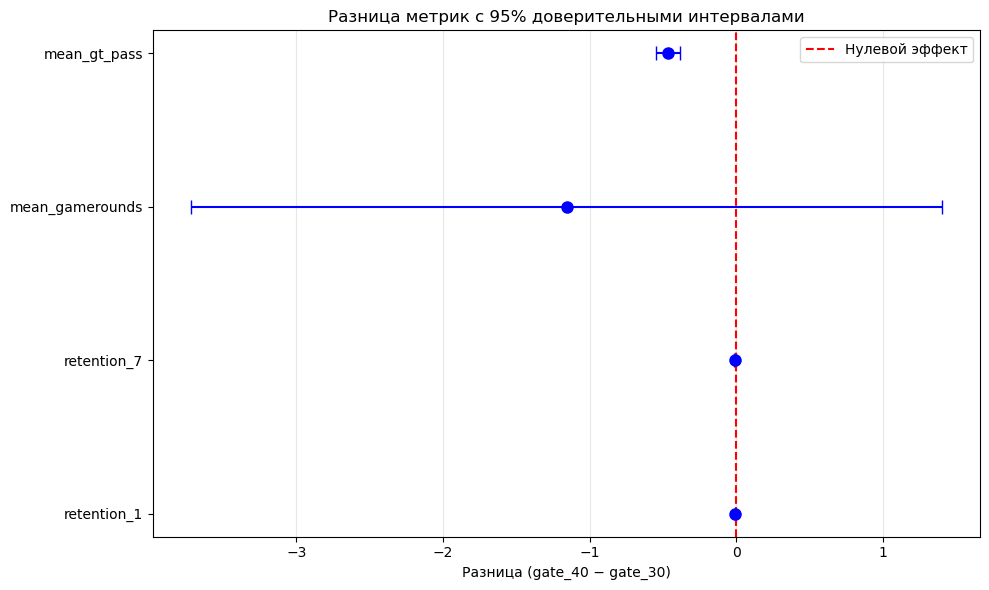

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(result))
ax.errorbar(
    result['difference'], y_pos,
    xerr=[result['difference'] - result['CI_95%_lower'],
          result['CI_95%_upper'] - result['difference']],
    fmt='o', capsize=5, color='blue', markersize=8
)
ax.axvline(0, color='red', linestyle='--', label='Нулевой эффект')



ax.set_yticks(y_pos)
ax.set_yticklabels(result['metric'])
ax.set_xlabel('Разница (gate_40 − gate_30)')
ax.set_title('Разница метрик с 95% доверительными интервалами')
ax.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##  Выводы

### Основные результаты:

| Метрика | gate_30 | gate_40 | Разница | p-value | Значимо |
|---------|---------|---------|---------|---------|---------|
| retention_1 | 44.8% | 44.2% | −0.6 п.п. | 0.074 | Нет |
| retention_7 | 19.0% | 18.2% | −0.8 п.п. | 0.002 | Да |
| mean_gamerounds | 52.5 | 51.3 | −1.2 | 0.376 | Нет |
| mean_gt_pass | 1.75 | 1.28 | −0.47 | <0.001 | Да |

###  Интерпретация:

**Версия `gate_30` показывает ЛУЧШИЕ результаты по всем метрикам:**

1.  **retention_7** статистически значимо выше на 0.8 п.п. (p=0.002)
   - Относительный прирост: **+4.5%**
   - 95% ДИ: [0.3%, 1.3%] — интервал не содержит 0
   - Игроки чаще возвращаются через 7 дней

2. **gt_pass** (пройденные гейты) значимо выше на 0.47 (p<0.001)
   - Относительный прирост: **+36.6%**
   - **Это напрямую влияет на выручку!** Больше пройденных гейтов = больше показов рекламы и покупок

3.  **retention_1** и **mean_gamerounds** тоже выше для gate_30, 
   но разница не достигла статистической значимости (p > 0.05)


**РЕКОМЕНДУЮ оставить версию `gate_30`** по следующим причинам:
1. Статистически значимый рост retention_7 (+4.5% относительно)
2. Значимый рост пройденных гейтов (+36.6% относительно) — ключевая метрика для монетизации
3. Нет негативного влияния на другие метрики

### Следующие шаги:
1. Оставить gate_30 как основную версию
2. Оценить влияние на выручку (если есть данные о платежах)
3. Для метрик retention_1 и mean_gamerounds — увеличить выборку, 
   чтобы уменьшить доверительные интервалы и подтвердить тренд
